# Homework for lab 3 MLOps

In [45]:
import os
import polars as pl
import matplotlib.pyplot as plt

## Load Data

In [46]:
taxi_data_lazy = pl.scan_csv("data/taxi_zone_lookup.csv")

In [47]:
taxi_df = []
for month in range(1, 13):
    file_path = f"data/{month}.parquet"
    if os.path.exists(file_path):
        df = pl.scan_parquet(file_path)
        df = df.with_columns(
            pl.col("tpep_pickup_datetime").dt.cast_time_unit("ms"),
            pl.col("tpep_dropoff_datetime").dt.cast_time_unit("ms"),
        )
        taxi_df.append(df)

df_all = pl.concat(taxi_df)
#filter data until 01.01.2025
df_all = df_all.filter(
    pl.col("tpep_pickup_datetime").dt.year() == 2024,
    pl.col("tpep_dropoff_datetime") <= pl.lit("2025-01-01").str.strptime(pl.Date, "%Y-%m-%d")
)

In [ ]:
df_all = df_all.with_columns(
    pl.col("VendorID").cast(pl.Int8),
    pl.col("passenger_count").cast(pl.Int8),
    pl.col("RatecodeID").cast(pl.Int8),
    pl.col("PULocationID").cast(pl.Int16),
    pl.col("DOLocationID").cast(pl.Int16),
    pl.col("payment_type").cast(pl.Int8),
    pl.col("store_and_fwd_flag").cast(pl.Categorical),
    pl.col("fare_amount").cast(pl.Float32),
    pl.col("extra").cast(pl.Float32),
    pl.col("mta_tax").cast(pl.Float32),
    pl.col("tip_amount").cast(pl.Float32),
    pl.col("tolls_amount").cast(pl.Float32),
    pl.col("improvement_surcharge").cast(pl.Float32),
    pl.col("total_amount").cast(pl.Float32),
    pl.col("congestion_surcharge").cast(pl.Float32),
    pl.col("Airport_fee").cast(pl.Float32),
    pl.col("trip_distance").cast(pl.Float32),
)

## Data Cleaning

In [ ]:
df_clean = df_all.with_columns(
    pl.when(pl.col("passenger_count").fill_null(1) > 6).then(6).otherwise(pl.col("passenger_count").fill_null(1)).alias("passenger_count"),
    pl.col("fare_amount").abs(),
    pl.col("extra").abs(),
    pl.col("mta_tax").abs(),
    pl.col("tip_amount").abs(),
    pl.col("tolls_amount").abs(),
    pl.col("improvement_surcharge").abs(),
    pl.col("total_amount").abs(),
    pl.col("congestion_surcharge").abs(),
    pl.col("Airport_fee").abs(),
)



In [ ]:
df_clean = df_clean.filter(
    pl.col("passenger_count") > 0,
    (pl.col("tpep_dropoff_datetime") - pl.col("tpep_pickup_datetime")).dt.total_minutes() <= 120,
    pl.col("fare_amount") <= 1000,
    pl.col("extra") <= 1000,
    pl.col("mta_tax") <= 1000,
    pl.col("tip_amount") <= 1000,
    pl.col("tolls_amount") <= 1000,
    pl.col("improvement_surcharge") <= 1000,
    pl.col("total_amount") <= 1000,
    pl.col("congestion_surcharge") <= 1000,
    pl.col("Airport_fee") <= 1000,
    pl.col("VendorID").is_in([1, 2]),
    pl.col("RatecodeID").is_in([1, 2, 3, 4, 5, 6]),
)

## Transformation

In [ ]:
df_transformed = df_clean.with_columns(
    pl.when(pl.col("payment_type").is_in([1])).then(pl.lit("credit"))
    .when(pl.col("payment_type").is_in([2])).then(pl.lit("cash"))
    .otherwise(pl.lit("other")).alias("payment_type"),
    (pl.col("Airport_fee") > 0).alias("is_airport_ride"),
    pl.when(
        pl.col("tpep_pickup_datetime").dt.weekday() <= 5,  
        (
            ((pl.col("tpep_pickup_datetime").dt.hour() + pl.col("tpep_pickup_datetime").dt.minute() / 60).is_between(6.5, 9.5)) |
            ((pl.col("tpep_pickup_datetime").dt.hour() + pl.col("tpep_pickup_datetime").dt.minute() / 60).is_between(15.5, 20.0))
        )
    ).then(True).otherwise(False).alias("is_rush_hour")
)


In [65]:
df_transformed = df_transformed.join(
    taxi_data_lazy.select(["LocationID", "Borough"]).rename({"Borough": "PU_Borough"}),
    left_on="PULocationID",
    right_on="LocationID",
    how="left"
).join(
    taxi_data_lazy.select(["LocationID", "Borough"]).rename({"Borough": "DO_Borough"}),
    left_on="DOLocationID",
    right_on="LocationID",
    how="left"
)

In [66]:
df_transformed = df_transformed.select([
    "tpep_pickup_datetime", "passenger_count", "trip_distance", "RatecodeID", "payment_type",
    "fare_amount", "extra", "mta_tax", "tip_amount", "tolls_amount", "improvement_surcharge",
    "total_amount", "congestion_surcharge", "Airport_fee", "PU_Borough", "DO_Borough",
    "is_airport_ride", "is_rush_hour"
])

## Feature Extraction Pipeline

In [ ]:
df_daily = df_transformed.group_by(
    pl.col("tpep_pickup_datetime").dt.date().alias("date")
).agg(
    pl.len().alias("total_rides"),

    pl.col("is_airport_ride").sum().alias("airport_rides"),
    pl.col("is_rush_hour").sum().alias("rush_hour_rides"),
    pl.col("fare_amount").mean().alias("avg_fare_amount"),
    pl.col("trip_distance").median().alias("median_distance"),
    pl.col("total_amount").sum().alias("sum_total_amount"),
    pl.col("congestion_surcharge").sum().alias("total_congestion_surcharge"),
    pl.col("passenger_count").sum().alias("total_passengers"),
).sort("date")

df_daily = df_daily.with_columns(
    pl.col("date").dt.quarter().alias("quarter"),
    pl.col("date").dt.month().alias("month"),
    pl.col("date").dt.day().alias("day_of_month"),
    pl.col("date").dt.weekday().alias("day_of_week"),  
    (pl.col("date").dt.weekday() >= 6).alias("is_weekend"),
)

df_daily.collect().write_parquet("dataset.parquet")

## Data analysis


In [61]:
df_final = pl.read_parquet("dataset.parquet")

In [62]:
print(df_final.shape)
print(df_final.head())
print(df_final.describe())
print(df_final.schema)


(366, 14)
shape: (5, 14)
┌────────────┬────────────┬────────────┬───────────┬───┬───────┬───────────┬───────────┬───────────┐
│ date       ┆ total_ride ┆ airport_ri ┆ rush_hour ┆ … ┆ month ┆ day_of_mo ┆ day_of_we ┆ is_weeken │
│ ---        ┆ s          ┆ des        ┆ _rides    ┆   ┆ ---   ┆ nth       ┆ ek        ┆ d         │
│ date       ┆ ---        ┆ ---        ┆ ---       ┆   ┆ i8    ┆ ---       ┆ ---       ┆ ---       │
│            ┆ u32        ┆ u32        ┆ u32       ┆   ┆       ┆ i8        ┆ i8        ┆ bool      │
╞════════════╪════════════╪════════════╪═══════════╪═══╪═══════╪═══════════╪═══════════╪═══════════╡
│ 2024-01-01 ┆ 69541      ┆ 8352       ┆ 19415     ┆ … ┆ 1     ┆ 1         ┆ 1         ┆ false     │
│ 2024-01-02 ┆ 71444      ┆ 9828       ┆ 30654     ┆ … ┆ 1     ┆ 2         ┆ 2         ┆ false     │
│ 2024-01-03 ┆ 78399      ┆ 9140       ┆ 33060     ┆ … ┆ 1     ┆ 3         ┆ 3         ┆ false     │
│ 2024-01-04 ┆ 97896      ┆ 8270       ┆ 43267     ┆ … ┆ 1     ┆ 4

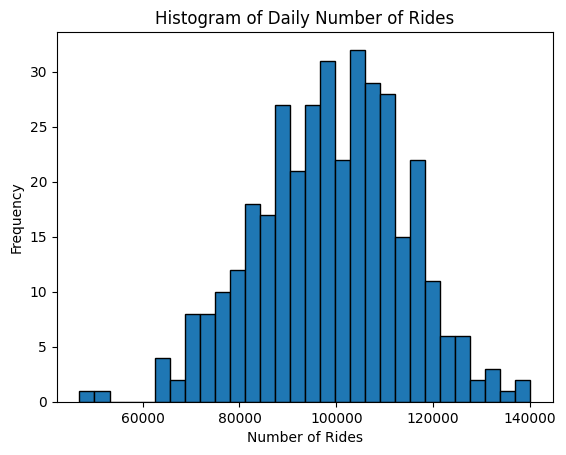

In [63]:
plt.hist(df_final["total_rides"], bins=30, edgecolor='black')
plt.title("Histogram of Daily Number of Rides")
plt.xlabel("Number of Rides")
plt.ylabel("Frequency")
plt.show()

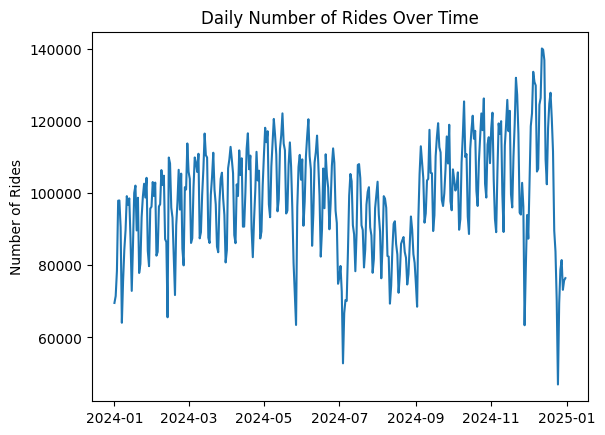

In [64]:
plt.plot(df_final["date"], df_final["total_rides"])
plt.title("Daily Number of Rides Over Time")
plt.ylabel("Number of Rides")
plt.show()